## Diseño de PID mediante LGR para la planta termica

Partimos desde la función de transferencia de lazo abierto ($G_{PID}(s)$) y nuestra funcion de transferencia de planta termica ($G(s)$):

$$ G_{PID}(S) = K_p (1 + \frac{1}{T_i s} + T_d s) $$

$$ G(S) = \frac{K}{\tau s + 1} e^{\theta_d s} $$

Hacemos la comprobación de nuestra función de lazo cerrado $ L(s) $

$$ L(s) = G_{PID}(s) G(s) =  K_p (1 + \frac{1}{T_i s} + T_d s) \ \frac{K}{\tau s + 1} $$

In [25]:
import control as ctrl
import numpy as np
import sympy as sp
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import savgol_filter

Comprobación del codigo

## Trazado de Lugar Geométrico de las Raíces

Procedemos a gráficar el lugar geométrico de las raíces de $L(s)$, variando $K_p$

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


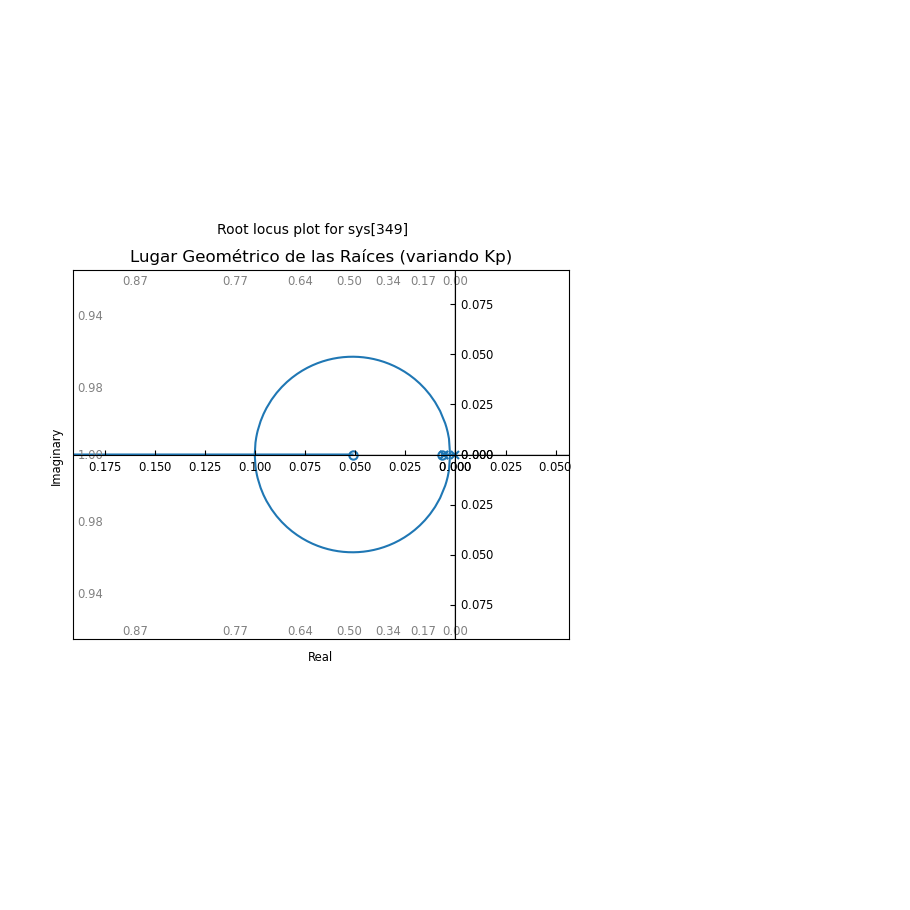

In [26]:
K = 1
tau = 172.61

Ti = tau
Td = tau / 10

# Sistema sin Kp
num = [Td * Ti, Ti, 1]
den = [Ti * tau, Ti, 0]

C_base = ctrl.tf(num, den)
G = ctrl.tf([K], [tau, 1])

L_base = C_base * G

# Root locus (Kp variable automáticamente)
plt.figure()
ctrl.root_locus(L_base)
plt.title('Lugar Geométrico de las Raíces (variando Kp)')
plt.grid()
plt.show()

Cada uno de estos polos hace cambios notables en la respuesta de nuestro sistema, la gráfica no se puede observar de manera muy clara como la ganancia va afectando al sistema como tal, por eso para hacer el ejemplo mucho más ilustrativo incluyo las respuestas a cada uno de estos K empleados para así entender mejor como se esta llegando despues a las especificaciones proximas.

Kp = 0.5, polos = [-0.00636807+0.j         -0.00275421+0.00277159j -0.00275421-0.00277159j]
Kp = 1, polos = [-0.00642944+0.j        -0.00286836+0.0046921j -0.00286836-0.0046921j]
Kp = 2, polos = [-0.00313674+0.00708869j -0.00313674-0.00708869j -0.00647202+0.j        ]
Kp = 5, polos = [-0.00398975+0.01155701j -0.00398975-0.01155701j -0.00650401+0.j        ]
Kp = 17.68, polos = [-0.00765391+0.02164605j -0.00765391-0.02164605j -0.00652174+0.j        ]


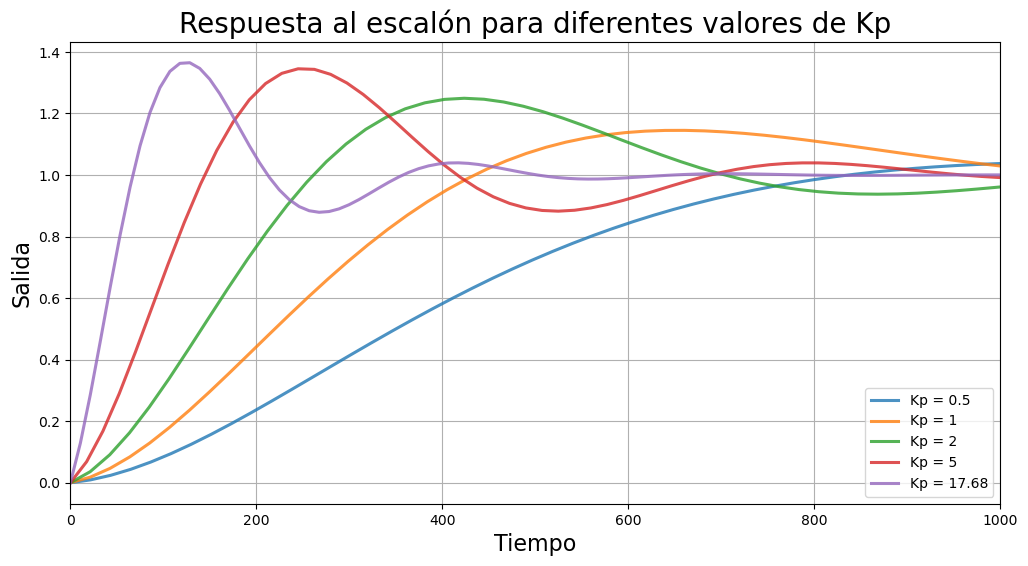

In [27]:
# Step response para distintos Kp
Kp_values = [0.5, 1, 2, 5, 17.68]

plt.figure(figsize=(12, 6))

for Kp in Kp_values:
    L = Kp * L_base
    T = ctrl.feedback(L, 1)
    
    # Polos del sistema
    print(f"Kp = {Kp}, polos = {ctrl.poles(T)}")
    
    # Respuesta al escalón
    t, y = ctrl.step_response(T)
    plt.plot(t, y, label=f"Kp = {Kp}", linewidth=2.2, alpha=0.8)

plt.title('Respuesta al escalón para diferentes valores de Kp', fontsize=20)
plt.xlabel('Tiempo',fontsize=16)
plt.ylabel('Salida',fontsize=16)
plt.grid()
plt.legend()

plt.xlim(0, 1000)
plt.show()

## Requisitos de Diseño

In [28]:
# Especificaciones
OS = 10          # % sobreimpulso
Ts = 120         # tiempo de asentamiento (s)

# -----------------------------
# 1. Calcular zeta
# -----------------------------
zeta = -np.log(OS/100) / np.sqrt(np.pi**2 + (np.log(OS/100))**2)

# -----------------------------
# 2. Calcular frecuencia natural wn
# -----------------------------
wn = 4 / (zeta * Ts)

# -----------------------------
# 3. Calcular polos deseados
# -----------------------------
sigma = -zeta * wn
wd = wn * np.sqrt(1 - zeta**2)

s1 = complex(sigma, wd)
s2 = complex(sigma, -wd)

print("zeta =", zeta)
print("wn =", wn)
print("s1 =", s1)
print("s2 =", s2)

zeta = 0.5911550337988976
wn = 0.05638678760650266
s1 = (-0.03333333333333334+0.045479211794728046j)
s2 = (-0.03333333333333334-0.045479211794728046j)


## Calculo de Ti, Td

In [29]:
# Vars
Ti, Td = sp.symbols('Ti Td', real=True)

# Datos
Kp = 17.63
tau = 172.61

# Polo deseado
s = s1

# Definir L(s)
num = Ti*Td*s**2 + Ti*s + 1
den = Ti*s*(tau*s + 1)

L = Kp * num / den

# -----------------------------
# ECUACIÓN 1: fase → Im(L) = 0
# -----------------------------
eq1 = sp.im(L)

# -----------------------------
# ECUACIÓN 2: módulo → |L| = 1
# -----------------------------
eq2 = sp.re(L)**2 + sp.im(L)**2 - 1

# -----------------------------
# Intentar resolver
# -----------------------------
sol = sp.nsolve(
    [eq1, eq2],
    [Ti, Td],
    [100, 10],  # intenta también otros iniciales
    tol=1e-6,   # relajar tolerancia
    maxsteps=100
)

# Problemas de metodo de optimización
print("Ti =", float(sol[0]))
print("Td =", float(sol[1]))

Ti = 19.842366992978427
Td = 6.060122899507725


Cabe aclarar que la tolerancia y parametros empleados para el metodo **nsolve** fueron determinados desde el tanteo y que se pudiera observar una respuesta coherente al problema, la sensibilidad de evaluar esto recae más en el metodo númerico empleado y no como fue formulado la llegada a los valores de $T_i$ y $T_d$

In [30]:
Ti_val = float(sol[0])
Td_val = float(sol[1])

sd = s1

num = Ti_val*Td_val*sd**2 + Ti_val*sd + 1
den = Ti_val*sd*(tau*sd + 1)

L_val = Kp * num / den

print("Magnitud:", abs(L_val))
print("Fase (deg):", np.degrees(np.angle(L_val)))

Magnitud: 1.0000002249825175
Fase (deg): 179.99999809469213


## Simulación y Verificación

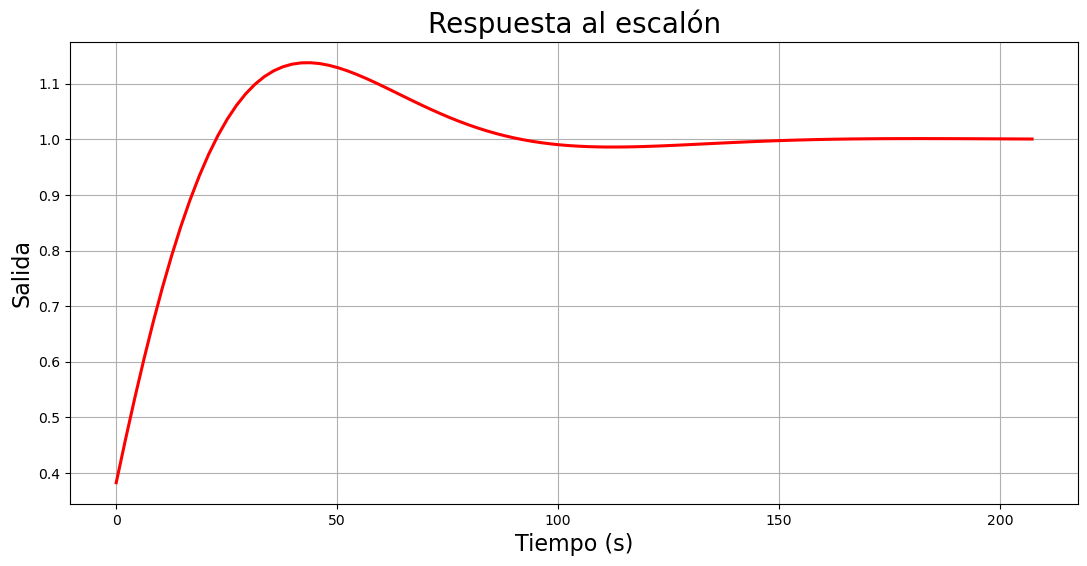

Sobreimpulso (%OS): 13.787462824390339
Tiempo de asentamiento Ts (s): 83.73035704592311
Tiempo de subida: 18.8393303353327
Close loop poles: [-0.03333334+0.04547921j -0.03333334-0.04547921j]
Close loop poles desired: (-0.03333333333333334+0.045479211794728046j)


In [31]:
# Tus valores obtenidos
tau = 172.61

Ti = Ti_val
Td = Td_val

# Controlador PID
numC = [Kp*Td*Ti, Kp*Ti, Kp]
denC = [Ti, 0]

C = ctrl.tf(numC, denC)

# Planta
G = ctrl.tf([1], [tau, 1])

# Lazo abierto
L = C * G

# Lazo cerrado
T = ctrl.feedback(L, 1)

t, y = ctrl.step_response(T)

plt.figure(figsize=(13, 6))
plt.plot(t, y, linewidth=2.2, color='red')
plt.title("Respuesta al escalón",fontsize=20)
plt.xlabel("Tiempo (s)",fontsize=16)
plt.ylabel("Salida",fontsize=16)
#plt.ylim(0, 1.5)
plt.grid()
plt.show()

info = ctrl.step_info(T)

print("Sobreimpulso (%OS):", info['Overshoot'])
print("Tiempo de asentamiento Ts (s):", info['SettlingTime'])
print("Tiempo de subida:", info['RiseTime'])
print("Close loop poles:", ctrl.poles(T))
print("Close loop poles desired:", s)

# 60 - 120 segundos

## Espacio de datos reales

Esta sección recopila todos los datos obtenidos desde la práctica con la planta real y la simulación hecha en TCLABModel

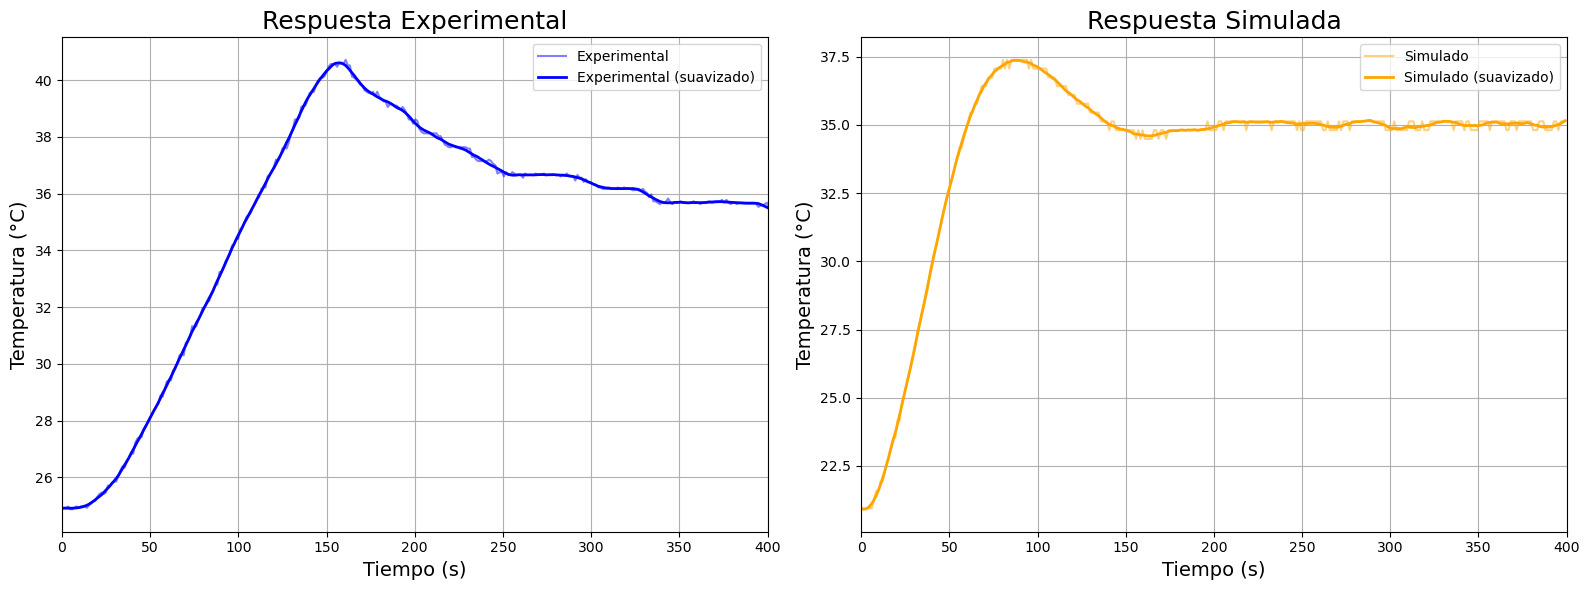

In [45]:
# Open file
data = pd.read_csv('PRUEBAS PID LGR/data_17.63.txt', encoding='latin1', sep=',')
data_2 = pd.read_csv('PRUEBAS PID LGR/SIMULADO/data.txt', encoding='latin1', sep=',')

# Extract data
time = data['Tiempo (s)']
temperature = data[' Temp1 (°C)']
time_2 = data_2['Tiempo (s)']
temperature_2 = data_2[' Temp1 (°C)']

# Softer curve using Savitzky-Golay filter
temperature_smooth = savgol_filter(temperature, window_length=21, polyorder=3)
temperature_2_smooth = savgol_filter(temperature_2, window_length=21, polyorder=3)

# Plot de los datos experimentales y simulados subfigures
plt.subplots(1, 2, figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.plot(time, temperature, label='Experimental', color='blue', alpha=0.5)
plt.plot(time, temperature_smooth, label='Experimental (suavizado)', color='blue', linewidth=2)
plt.title('Respuesta Experimental', fontsize=18)
plt.xlabel('Tiempo (s)', fontsize=14)
plt.ylabel('Temperatura (°C)', fontsize=14)
plt.xlim(0, 400)
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(time_2, temperature_2, label='Simulado', color='orange', alpha=0.5)
plt.plot(time_2, temperature_2_smooth, label='Simulado (suavizado)', color='orange', linewidth=2)
plt.title('Respuesta Simulada', fontsize=18)
plt.xlabel('Tiempo (s)', fontsize=14)
plt.ylabel('Temperatura (°C)', fontsize=14)
plt.grid()
plt.xlim(0, 400)
plt.legend()
plt.tight_layout()
plt.show()


Ignorando las grandes diferencias propiciadas por ruido y los sensores, se puede ver una semejanza en la forma que responden nuestros sistemas, la gran diferencia observable en nuestro proceder esta dada en la caida de la temperatura, esto puede ser debido a distintos factores externos a la prueba como tal y tambien teniendo en cuenta que previo a las pruebas que realizamos tuvimos problemas de tiempo de respuesta inicial por un cuello de botella producido por el amperaje empleado en las pruebas iniciales.